# Life Expectancy — Part 2: Supervised Machine Learning


## Load Cleaned Dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, confusion_matrix,
                              classification_report, roc_curve, roc_auc_score,
                              precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("cleaned_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Define Feature Matrix & Labels

- **`y_reg`**: continuous target = `Life expectancy`
- **`y_clf`**: binary target derived by binarizing `y_reg` at its median — `(y_reg > y_reg.median()).astype(int)`
- **`X`**: all remaining columns, with `Country` dropped (193 unique values — too high-cardinality to be a useful generalizable feature; one-hot encoding it would add 192 sparse columns and risk severe overfitting, while label-encoding it would impose a meaningless numeric order on country names).

In [2]:
TARGET = "Life expectancy"

X = df.drop(columns=[TARGET, "Country"]).copy()

y_reg = df[TARGET].copy()
y_clf = (y_reg > y_reg.median()).astype(int)

print(f"y_reg  : continuous target = '{TARGET}'")
print(f"y_clf  : binary target = (Life expectancy > median={y_reg.median():.2f}).astype(int)")
print(f"Feature matrix X shape: {X.shape}")
print(f"\ny_clf distribution:")
print(y_clf.value_counts())

y_reg  : continuous target = 'Life expectancy'
y_clf  : binary target = (Life expectancy > median=72.10).astype(int)
Feature matrix X shape: (2938, 20)

y_clf distribution:
Life expectancy
0    1485
1    1453
Name: count, dtype: int64


## Encode Categorical Columns

`Status` is the only categorical column remaining in `X` (`Country` was dropped above). It has two values: **"Developing"** and **"Developed"**. This is a natural binary ordinal feature — "Developed" represents a strictly higher level of economic and health-system development than "Developing" — so we apply a simple, order-preserving label encoding: `Developing = 0`, `Developed = 1`.

In [3]:
print(f"Categorical columns in X: {X.select_dtypes(include=['object','category']).columns.tolist()}")

status_map = {"Developing": 0, "Developed": 1}
X["Status"] = X["Status"].map(status_map)

print("\n'Status' label-encoded: Developing=0, Developed=1")
print(f"\nRemaining non-numeric columns: {X.select_dtypes(include=['object','category']).columns.tolist()}")
X.dtypes

Categorical columns in X: ['Status']

'Status' label-encoded: Developing=0, Developed=1

Remaining non-numeric columns: []


Year                                 int64
Status                               int64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

## Leak-Free Train-Test Split & Scaling

The `StandardScaler` is fit **only** on `X_train`, then used to transform both `X_train` and `X_test`. Fitting the scaler on the full dataset (including test rows) would leak test-set mean/variance statistics into the training process — the model would implicitly "see" information about the test distribution before evaluation, inflating performance estimates and violating the train/test separation that makes the evaluation meaningful.

In [4]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaler fit on X_train only; applied to both X_train and X_test.")

X_train: (2350, 20)   X_test: (588, 20)
Scaler fit on X_train only; applied to both X_train and X_test.


## Linear Regression

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_reg_train)
y_pred_reg = lin_reg.predict(X_test_scaled)

mse_lin = mean_squared_error(y_reg_test, y_pred_reg)
r2_lin  = r2_score(y_reg_test, y_pred_reg)

print(f"MSE: {mse_lin:.4f}")
print(f"R^2: {r2_lin:.4f}")

coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nCoefficients (sorted by |value|):")
display(coef_df)

top3_features = coef_df.head(3)
print("Top-3 |coefficient| features:")
display(top3_features)

MSE: 15.2923
R^2: 0.8236

Coefficients (sorted by |value|):


,feature,coefficient
9,under-five deaths,-11.040291
3,infant deaths,10.848067
2,Adult Mortality,-2.598476
13,HIV/AIDS,-2.421012
19,Schooling,2.072401
18,Income composition of resources,1.241183
12,Diphtheria,0.988182
8,BMI,0.820254
10,Polio,0.648993
1,Status,0.638248


Top-3 |coefficient| features:


,feature,coefficient
9,under-five deaths,-11.040291
3,infant deaths,10.848067
2,Adult Mortality,-2.598476


### Additional Graph: Top 10 OLS Coefficients

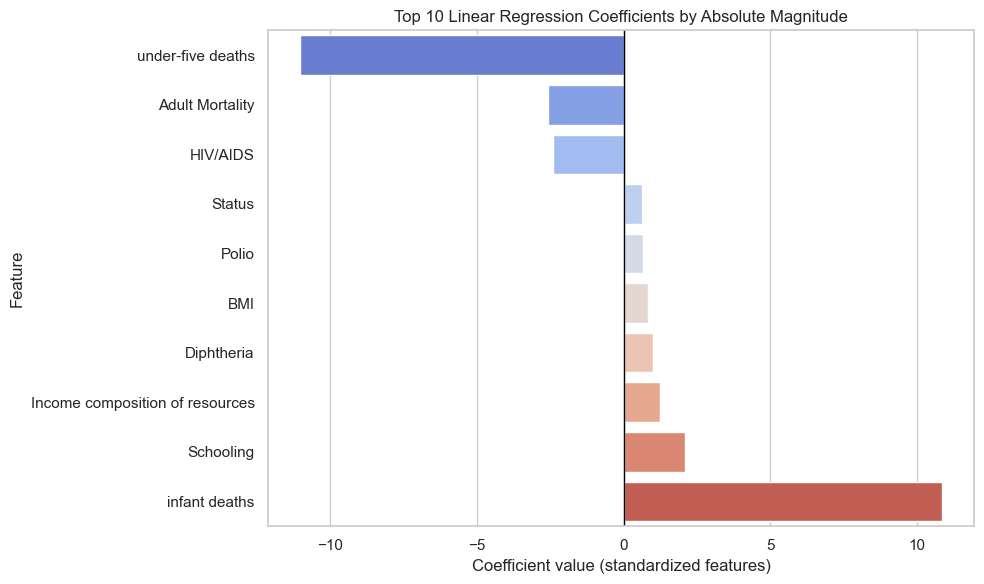

In [6]:
# Additional Graph: Top 10 OLS coefficients by absolute magnitude.
coef_plot_df = coef_df.assign(abs_coefficient=coef_df["coefficient"].abs()).head(10).sort_values("coefficient")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=coef_plot_df, x="coefficient", y="feature", ax=ax, palette="coolwarm")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top 10 Linear Regression Coefficients by Absolute Magnitude")
ax.set_xlabel("Coefficient value (standardized features)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## Ridge Regression (alpha=1.0)

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_reg_test, y_pred_ridge)
r2_ridge  = r2_score(y_reg_test, y_pred_ridge)

print(f"MSE: {mse_ridge:.4f}")
print(f"R^2: {r2_ridge:.4f}")

comp_table = pd.DataFrame({
    "Model": ["Linear Regression (OLS)", "Ridge (alpha=1.0)"],
    "MSE": [mse_lin, mse_ridge],
    "R2": [r2_lin, r2_ridge]
})
print("\nComparison Table:")
display(comp_table)

ridge_coef_df = pd.DataFrame({
    "feature": X.columns,
    "ols_coef": lin_reg.coef_,
    "ridge_coef": ridge.coef_
})
print("\nOLS vs Ridge coefficients:")
display(ridge_coef_df)

MSE: 15.3267
R^2: 0.8232

Comparison Table:


,Model,MSE,R2
0,Linear Regression (OLS),15.292306,0.823552
1,Ridge (alpha=1.0),15.326661,0.823155



OLS vs Ridge coefficients:


,feature,ols_coef,ridge_coef
0,Year,-0.000666,-0.003988
1,Status,0.638248,0.636881
2,Adult Mortality,-2.598476,-2.603432
3,infant deaths,10.848067,9.526622
4,Alcohol,0.217975,0.201222
5,percentage expenditure,0.099763,0.105184
6,Hepatitis B,-0.457261,-0.463243
7,Measles,-0.264600,-0.281306
8,BMI,0.820254,0.823003
9,under-five deaths,-11.040291,-9.719058


## Logistic Regression — Class Imbalance Check

In [8]:
vc = y_clf_train.value_counts()
print("y_clf_train distribution:")
print(vc)
min_pct = vc.min() / vc.sum() * 100
print(f"\nMinority class %: {min_pct:.2f}%")

if min_pct < 35:
    print("Imbalance detected (< 35%). Applying SMOTE to training set only.")
    smote = SMOTE(random_state=42)
    X_train_res, y_clf_train_res = smote.fit_resample(X_train_scaled, y_clf_train)
    print(f"Before SMOTE: {y_clf_train.value_counts().to_dict()}")
    print(f"After  SMOTE: {pd.Series(y_clf_train_res).value_counts().to_dict()}")
else:
    print("No significant imbalance (>= 35%). Using data as-is; no resampling needed.")
    X_train_res, y_clf_train_res = X_train_scaled, y_clf_train

y_clf_train distribution:
Life expectancy
1    1178
0    1172
Name: count, dtype: int64

Minority class %: 49.87%
No significant imbalance (>= 35%). Using data as-is; no resampling needed.


## Logistic Regression (C=1.0, baseline)

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
log_reg.fit(X_train_res, y_clf_train_res)

y_pred_clf  = log_reg.predict(X_test_scaled)
y_proba_clf = log_reg.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_clf_test, y_pred_clf)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_clf_test, y_pred_clf))

auc_baseline = roc_auc_score(y_clf_test, y_proba_clf)
print(f"AUC: {auc_baseline:.4f}")

Confusion Matrix:
[[271  42]
 [ 25 250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       313
           1       0.86      0.91      0.88       275

    accuracy                           0.89       588
   macro avg       0.89      0.89      0.89       588
weighted avg       0.89      0.89      0.89       588

AUC: 0.9569


### ROC Curve

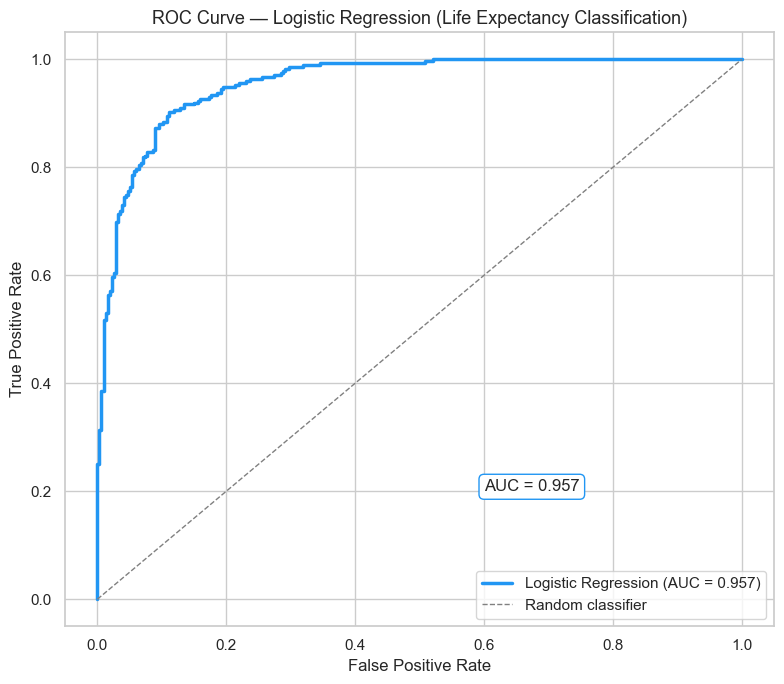

In [10]:
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_clf)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color="#2196F3", linewidth=2.5, label=f"Logistic Regression (AUC = {auc_baseline:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression (Life Expectancy Classification)", fontsize=13)
ax.annotate(f"AUC = {auc_baseline:.3f}", xy=(0.6, 0.2), fontsize=12,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="#2196F3"))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Decision-Threshold Sensitivity (0.30 to 0.70)

In [11]:
thresholds_list = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []
for t in thresholds_list:
    y_pred_t = (y_proba_clf >= t).astype(int)
    p  = precision_score(y_clf_test, y_pred_t)
    r  = recall_score(y_clf_test, y_pred_t)
    f1 = f1_score(y_clf_test, y_pred_t)
    threshold_results.append({"Threshold": t, "Precision": p, "Recall": r, "F1": f1})

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_threshold_row = threshold_df.loc[threshold_df["F1"].idxmax()]
print(f"F1-maximizing threshold: {best_threshold_row['Threshold']} (F1={best_threshold_row['F1']:.4f})")

,Threshold,Precision,Recall,F1
0,0.3,0.755682,0.967273,0.848485
1,0.4,0.808050,0.949091,0.872910
2,0.5,0.856164,0.909091,0.881834
3,0.6,0.894737,0.865455,0.879852
4,0.7,0.926724,0.781818,0.848126


F1-maximizing threshold: 0.5 (F1=0.8818)


### Additional Graph: Threshold Metric Trade-Off

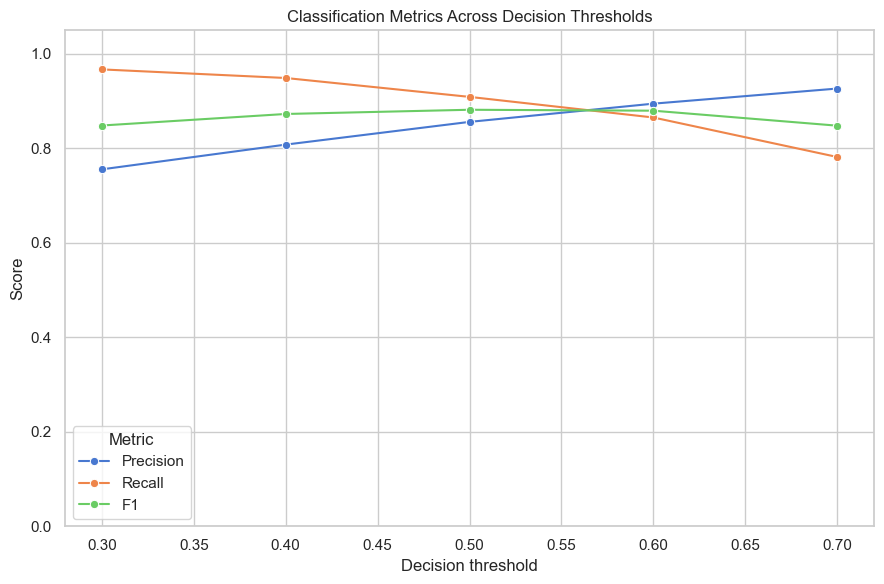

In [12]:
# Additional Graph: Precision, recall, and F1 across decision thresholds.
threshold_long = threshold_df.melt(id_vars="Threshold", value_vars=["Precision", "Recall", "F1"], var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=threshold_long, x="Threshold", y="Score", hue="Metric", marker="o", ax=ax)
ax.set_title("Classification Metrics Across Decision Thresholds")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Regularization Experiment: C=0.01 vs C=1.0

In [13]:
log_reg_strong = LogisticRegression(max_iter=1000, random_state=42, C=0.01)
log_reg_strong.fit(X_train_res, y_clf_train_res)

y_pred_strong  = log_reg_strong.predict(X_test_scaled)
y_proba_strong = log_reg_strong.predict_proba(X_test_scaled)[:, 1]

precision_baseline = precision_score(y_clf_test, y_pred_clf)
recall_baseline    = recall_score(y_clf_test, y_pred_clf)
auc_strong = roc_auc_score(y_clf_test, y_proba_strong)

precision_strong = precision_score(y_clf_test, y_pred_strong)
recall_strong    = recall_score(y_clf_test, y_pred_strong)

reg_comparison = pd.DataFrame({
    "Model": ["C=1.0 (baseline)", "C=0.01 (strong reg.)"],
    "Precision": [precision_baseline, precision_strong],
    "Recall": [recall_baseline, recall_strong],
    "AUC": [auc_baseline, auc_strong]
})
display(reg_comparison)

,Model,Precision,Recall,AUC
0,C=1.0 (baseline),0.856164,0.909091,0.956863
1,C=0.01 (strong reg.),0.835017,0.901818,0.947581


### Additional Graph: Regularization Metric Comparison

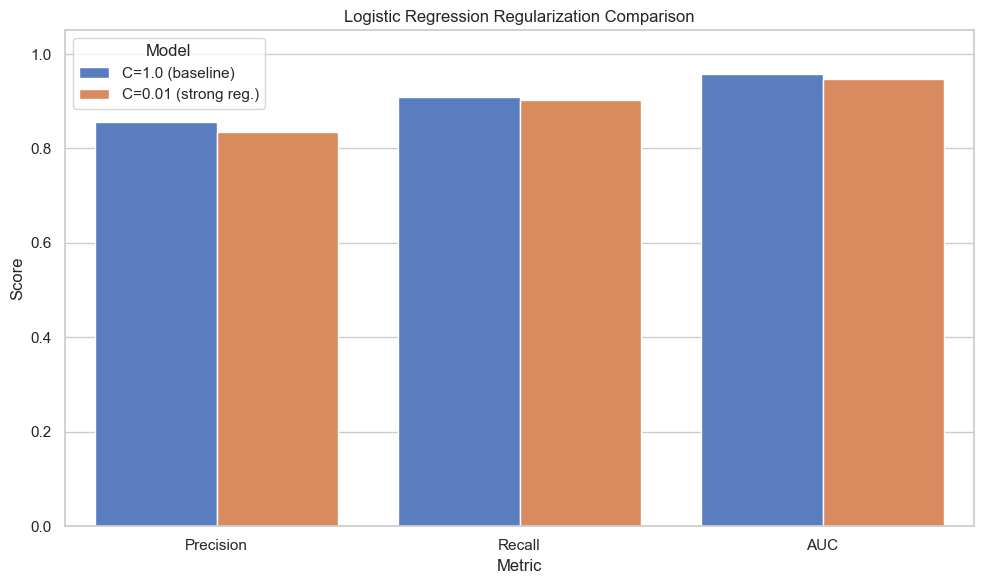

In [14]:
# Additional Graph: Baseline vs stronger regularization for logistic regression.
reg_long = reg_comparison.melt(id_vars="Model", value_vars=["Precision", "Recall", "AUC"], var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=reg_long, x="Metric", y="Score", hue="Model", ax=ax)
ax.set_title("Logistic Regression Regularization Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Bootstrap Confidence Interval for AUC Difference

In [15]:
np.random.seed(42)
n_boot = 500
y_clf_test_arr = y_clf_test.to_numpy()
auc_diffs = []

for i in range(n_boot):
    idx = np.random.choice(len(y_clf_test_arr), size=len(y_clf_test_arr), replace=True)
    y_sample = y_clf_test_arr[idx]
    if len(np.unique(y_sample)) < 2:
        continue
    proba_base_sample   = y_proba_clf[idx]
    proba_strong_sample = y_proba_strong[idx]
    auc_base_sample   = roc_auc_score(y_sample, proba_base_sample)
    auc_strong_sample = roc_auc_score(y_sample, proba_strong_sample)
    auc_diffs.append(auc_base_sample - auc_strong_sample)

auc_diffs = np.array(auc_diffs)
mean_diff = auc_diffs.mean()
ci_lower  = np.percentile(auc_diffs, 2.5)
ci_upper  = np.percentile(auc_diffs, 97.5)

print(f"Valid bootstrap samples: {len(auc_diffs)} / {n_boot}")
print(f"Mean AUC difference (C=1.0 - C=0.01): {mean_diff:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"CI excludes zero: {ci_lower > 0 or ci_upper < 0}")

Valid bootstrap samples: 500 / 500
Mean AUC difference (C=1.0 - C=0.01): 0.0093
95% CI: [0.0038, 0.0150]
CI excludes zero: True


---
**Part 2 analysis complete.** All metrics, tables, and plots are reproduced and interpreted in `README.md`.